In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.sim_params.default import DefaultParams

from src.traffic_sim import *
from src.plotting import *

In [57]:
optimal_vsl  = np.array(pd.read_csv("/Users/shreyaar/Desktop/PhD/research/MPC/results/warm_start/initial.csv"))
form_2_vsl = np.array(pd.read_csv("/Users/shreyaar/Desktop/PhD/research/MPC/results/warm_start/form_2.csv"))

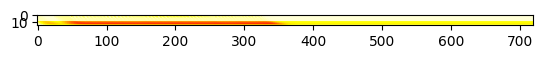

In [20]:
plt.imshow(optimal_vsl.T, cmap='hot', interpolation='nearest')

In [35]:
pred_horizon = 60
control_horizon = 30
sim_time = 720
time_step = 10/3600
L = 400/1000
time_steps = sim_time + pred_horizon - control_horizon

downstream_density = np.full(time_steps + 1, 0)
traffic_demand = [5500 if i in range(20, 20 + 180) else 4000 for i in range(time_steps + 1)]

total_distance = 6
num_segments = int(total_distance/L)

sim_lanes = {i: 4 if i < num_segments-5 else 2 for i in range(num_segments)}
segment_len = L
m=num_segments
hold_len = 1

i24params = DefaultParams(num_segments).get_params()

In [36]:
density, velocity, _, tts = metanet_sim_params(time_step, segment_len, (np.full(m, 0), np.full(m, 0), traffic_demand[0], 0), optimal_vsl, traffic_demand, downstream_density, i24params,
                                      lanes=sim_lanes, real_data=False, plotting=True)

In [37]:
print(i24params)

{'v_free': [120, 120, 120, 120, 120, 120, 120, 120, 120, 120, 120, 120, 120, 120, 120], 'a': [1.4, 1.4, 1.4, 1.4, 1.4, 1.4, 1.4, 1.4, 1.4, 1.4, 1.4, 1.4, 1.4, 1.4, 1.4], 'p_crit': [37.45, 37.45, 37.45, 37.45, 37.45, 37.45, 37.45, 37.45, 37.45, 37.45, 37.45, 37.45, 37.45, 37.45, 37.45], 'q_capacity': [2200, 2200, 2200, 2200, 2200, 2200, 2200, 2200, 2200, 2200, 2200, 2200, 2200, 2200, 2200], 'K': [40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40, 40], 'eta_high': [30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30], 'tau': [0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.005, 0.005]}


In [38]:
def V_func(v_free, a, rho, p_crit):
    return v_free * np.exp(-(1/a) * (rho / p_crit)**a)
vec_V = np.vectorize(V_func)
v_fd = vec_V(i24params['v_free'][0], i24params['a'][0], density[1:], i24params['p_crit'][0])
print(v_fd.shape)
print(optimal_vsl.shape)
v_equal = np.where(v_fd < optimal_vsl, 80, 0)

(720, 15)
(720, 15)


/var/folders/kl/txwf6c7d73v3xczbyqm3trhw0000gn/T/ipykernel_1320/1210164781.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/var/folders/kl/txwf6c7d73v3xczbyqm3trhw0000gn/T/ipykernel_1320/1210164781.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/var/folders/kl/txwf6c7d73v3xczbyqm3trhw0000gn/T/ipykernel_1320/1210164781.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


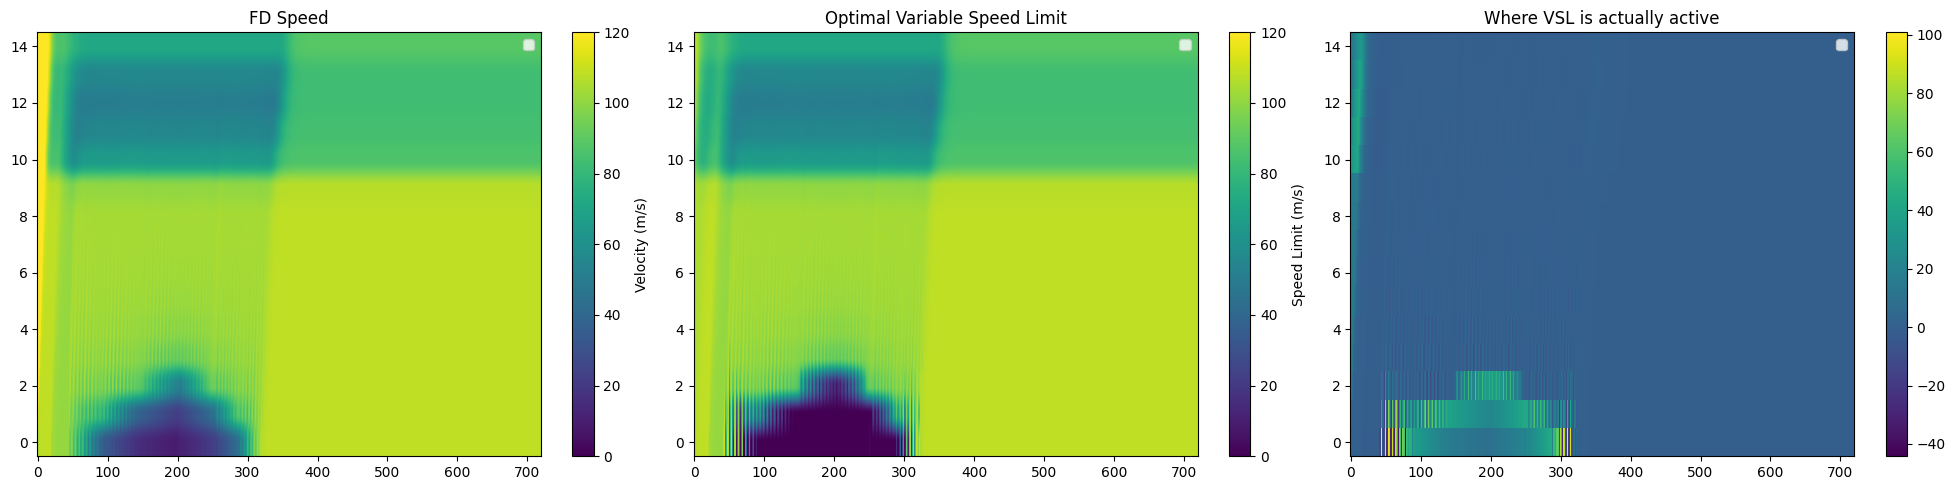

In [39]:
plt.figure(figsize=(20, 5))
plt.subplot(1, 3, 1)
plt.imshow(v_fd.T, aspect='auto', label='v_fd', vmax=120, vmin=0)
plt.title('FD Speed')
# plt.xlabel('Segment')
# plt.ylabel('Velocity (m/s)')
plt.colorbar(label='Velocity (m/s)')
plt.legend()
plt.gca().invert_yaxis()

plt.subplot(1, 3, 2)
plt.imshow(optimal_vsl.T, aspect='auto', label='Optimal VSL', vmax=120, vmin=0)
plt.title('Optimal Variable Speed Limit')
# plt.xlabel('Segment')
# plt.ylabel('Speed Limit (m/s)')
plt.colorbar(label='Speed Limit (m/s)')
plt.legend()
plt.tight_layout()
 
 #flip y axis
plt.gca().invert_yaxis()

plt.subplot(1, 3, 3)
plt.imshow(v_fd.T - optimal_vsl.T, aspect='auto', interpolation="none", vmax=np.max(v_fd - optimal_vsl), vmin=np.min(v_fd - optimal_vsl), label='v_fd - Optimal VSL')
plt.title('Where VSL is actually active')
# plt.xlabel('Segment')
# plt.ylabel('Speed Limit (m/s)')
plt.colorbar()
plt.legend()
plt.tight_layout()
 
 #flip y axis
plt.gca().invert_yaxis()

plt.show()


In [52]:
extended_vsl = np.where(v_fd - optimal_vsl <= 0.5, i24params['v_free'][0], optimal_vsl)

In [53]:
pd.DataFrame(extended_vsl).to_csv("/Users/shreyaar/Desktop/PhD/research/MPC/results/warm_start/extended_vsl.csv", index=False)

In [54]:
density_ext, velocity_ext, _, tts_ext = metanet_sim_params(time_step, segment_len, (np.full(m, 0), np.full(m, 0), traffic_demand[0], 0), extended_vsl, traffic_demand, downstream_density, i24params,
                                      lanes=sim_lanes, real_data=False, plotting=True)

print(tts, tts_ext)

671.2192058729456 671.1304904730041


720 15


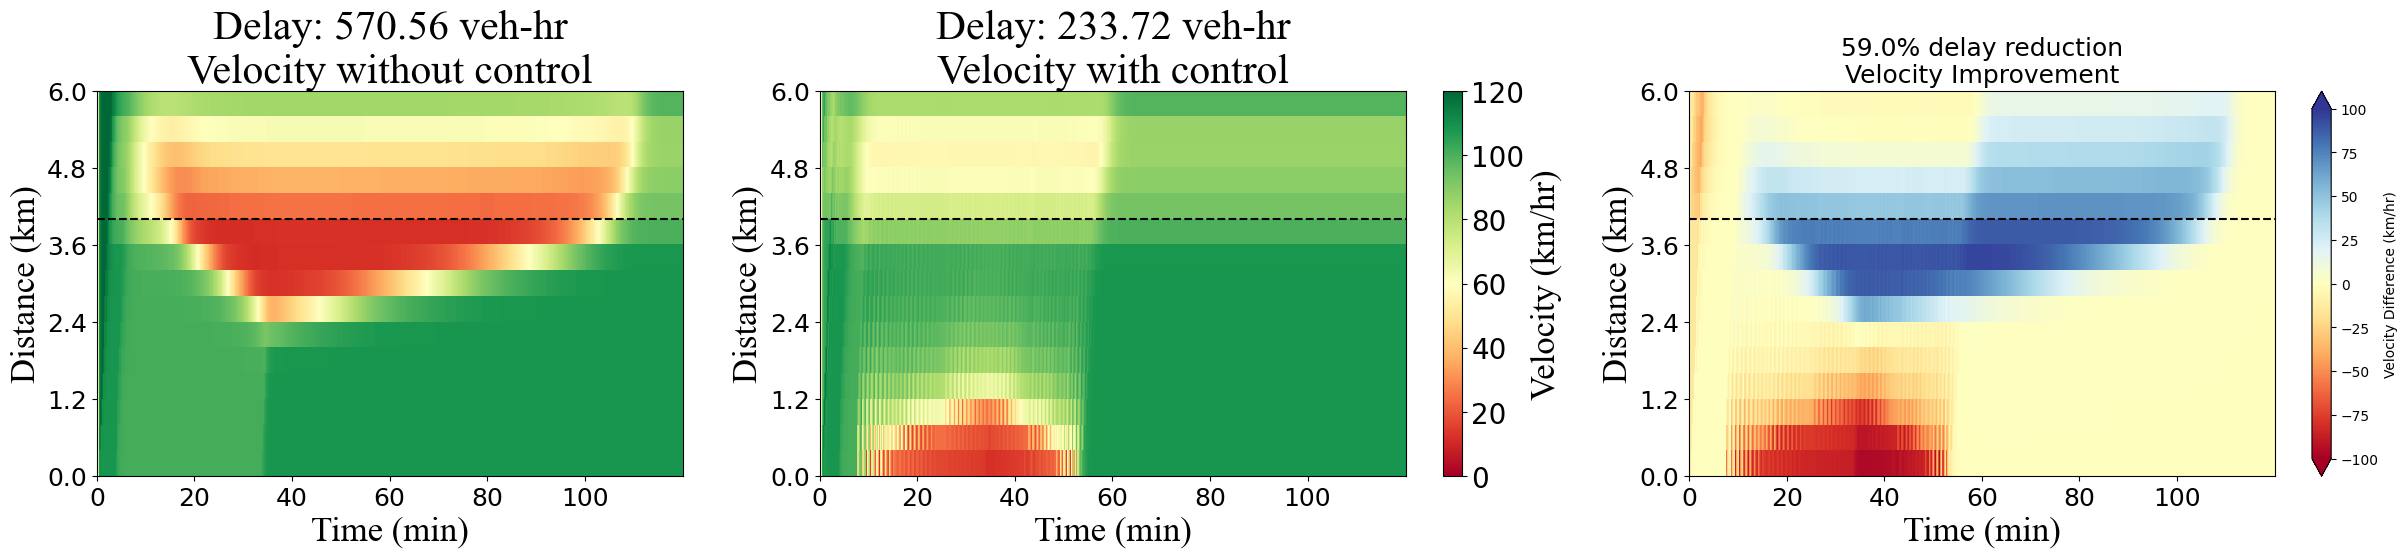

In [59]:
plot_nocontrol_control(traffic_demand, downstream_density, optimal_vsl, sim_lanes, i24params['v_free'][0], T=time_step, l=segment_len, plot_p=False, plot_q=False, params=i24params)

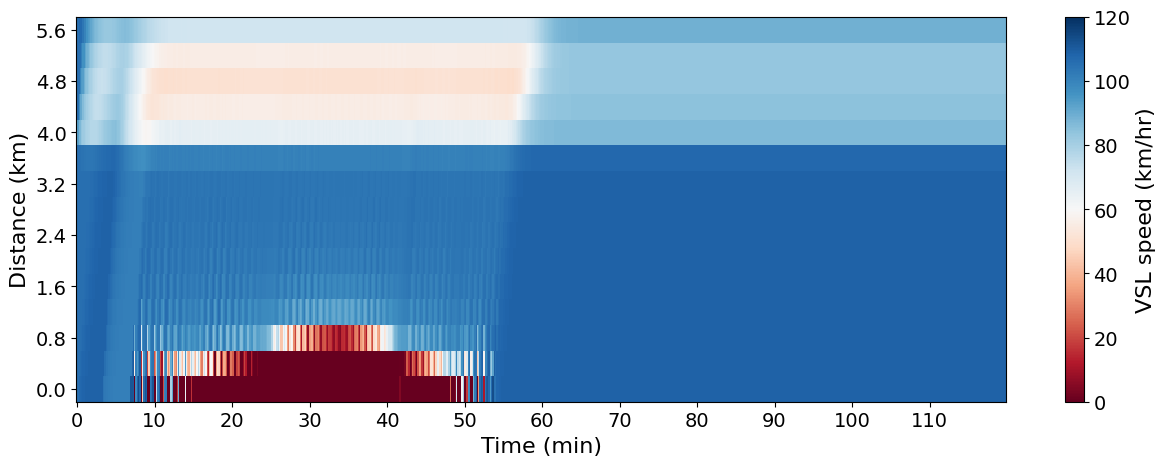

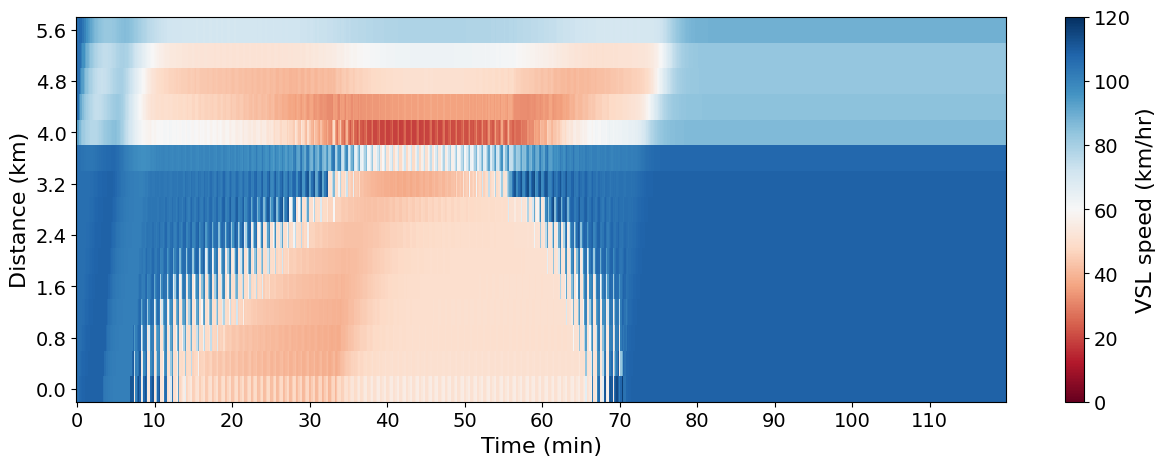

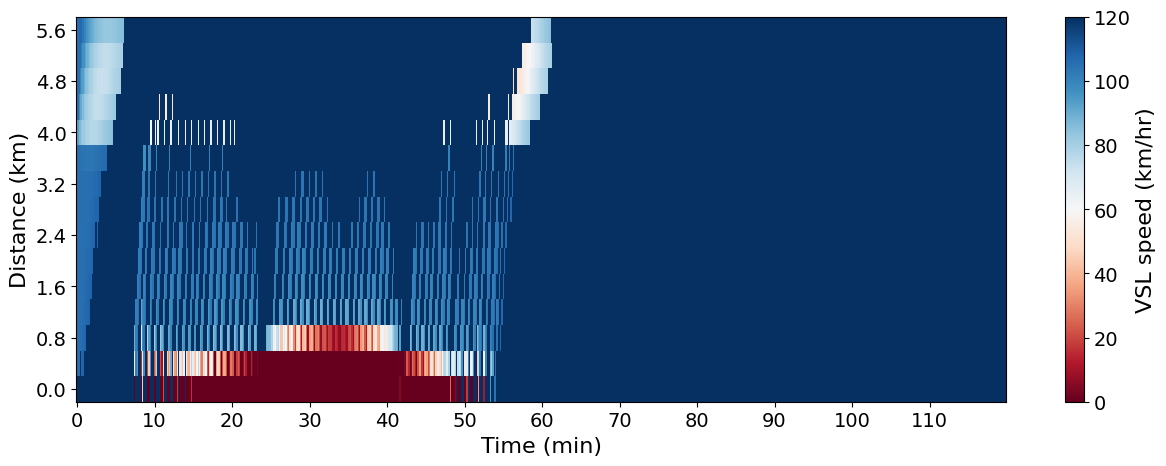

In [56]:
plot_vsls(optimal_vsl, sim_time, num_segments, i24params['v_free'][0], T=time_step, l=L)
plot_vsls(form_3_vsl, sim_time, num_segments, i24params['v_free'][0], T=time_step, l=L)
plot_vsls(extended_vsl, sim_time, num_segments, i24params['v_free'][0], T=time_step, l=L)

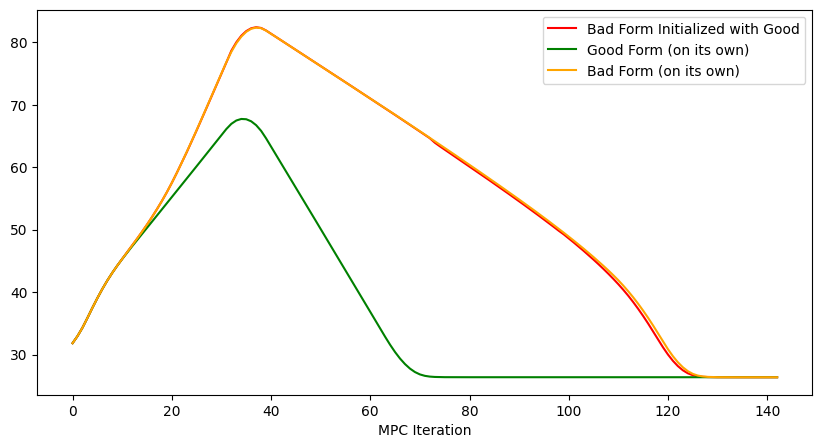

In [17]:
# Plot csv in '/Users/shreyaar/Desktop/PhD/research/MPC/warmstart_obj_trends'

bad_form_init_good = np.array(pd.read_csv("/Users/shreyaar/Desktop/PhD/research/MPC/warmstart_obj_trends/bad_form_initialized_with_extended.csv"))
good_form = np.array(pd.read_csv("/Users/shreyaar/Desktop/PhD/research/MPC/warmstart_obj_trends/good_form.csv"))
good_form_init = np.array(pd.read_csv("/Users/shreyaar/Desktop/PhD/research/MPC/warmstart_obj_trends/extended_init.csv"))
bad_form = np.array(pd.read_csv("/Users/shreyaar/Desktop/PhD/research/MPC/warmstart_obj_trends/bad_form.csv"))

# print(bad_form_init_good.shape, good_form.shape, good_form_init.shape, bad_form.shape)

plt.figure(figsize=(10, 5))
plt.plot(bad_form_init_good, label='Bad Form Initialized with Good', color='red')
plt.plot(good_form, label='Good Form (on its own)', color='green')
#plt.plot(good_form_init, label='Good Form Initialization', color='blue')
plt.plot(bad_form, label='Bad Form (on its own)', color='orange')

plt.xlabel('MPC Iteration')
plt.legend()
plt.show()

